# Text Extraction on Plate Number

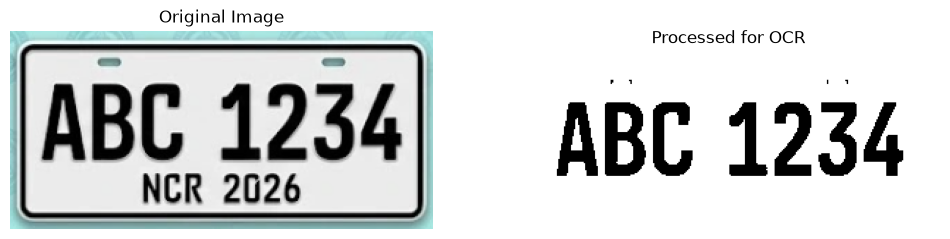

Extracted Text: ABC 1234


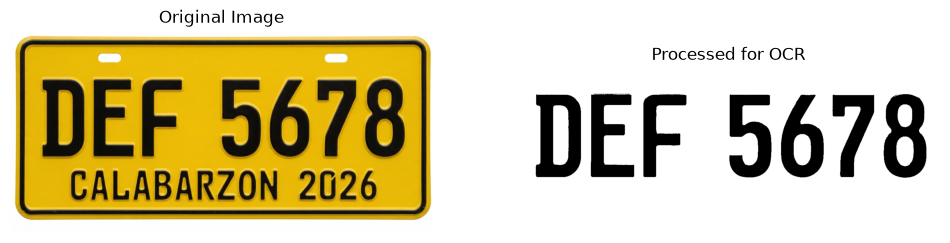

Extracted Text: DEF 5678


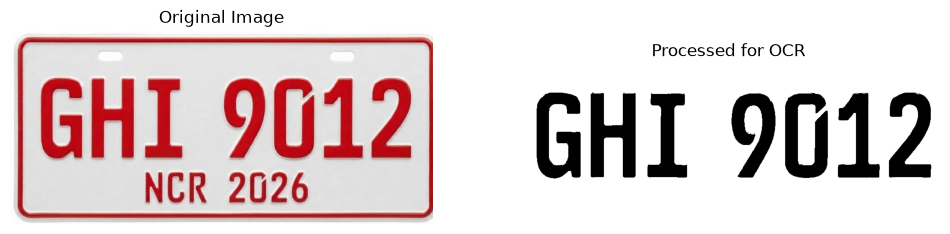

Extracted Text: GHI 9012


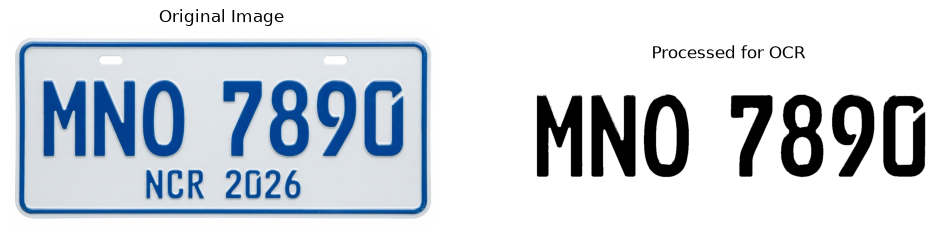

Extracted Text: MNO 7890


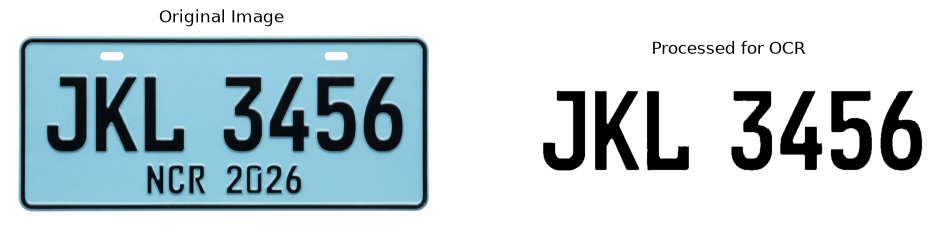

Extracted Text: JKL 3456


In [35]:
import cv2
import pytesseract
from matplotlib import pyplot as plt

# --- OPTIONAL: If tesseract is not in PATH, set the path manually ---
# For Windows, uncomment and adjust:
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

def ocr_image(image_path):
    img = cv2.imread(image_path)
    h, w = img.shape[:2]

    # Crop to the plate number line (skips the border and the bottom text)
    crop = img[int(h * 0.15):int(h * 0.68), int(w * 0.05):int(w * 0.95)]

    # Grayscale + Otsu threshold
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Make sure it's black text on white background
    if cv2.countNonZero(thresh) < thresh.size / 2:
        thresh = cv2.bitwise_not(thresh)

    # Add white padding
    thresh = cv2.copyMakeBorder(thresh, 20, 20, 20, 20, cv2.BORDER_CONSTANT, value=255)

    # Read as a single line of text
    text = pytesseract.image_to_string(thresh, config="--psm 7").strip()

    # Show original and processed image
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axs[0].set_title("Original Image")
    axs[0].axis("off")
    axs[1].imshow(thresh, cmap="gray")
    axs[1].set_title("Processed for OCR")
    axs[1].axis("off")
    plt.show()

    return text


# Example usage
text_output = ocr_image("Images/plate_number-private.png")
print("Extracted Text:", text_output)

text_output = ocr_image("Images/plate_number-public_utility.png")
print("Extracted Text:", text_output)

text_output = ocr_image("Images/plate_number-government.png")
print("Extracted Text:", text_output)

text_output = ocr_image("Images/plate_number-diplomatic.png")
print("Extracted Text:", text_output)

text_output = ocr_image("Images/plate_number-others.png")
print("Extracted Text:", text_output)
